<a href="https://colab.research.google.com/github/Shashi-kumar-g/machine-learning-26/blob/main/day3_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor

# Random seed
SEED = 42
rng = np.random.default_rng(SEED)

# Noise level
SIGMA = 0.3

# True function
f = lambda x: np.sin(2 * np.pi * x)

print("Random seed:", SEED)
print("Noise standard deviation:", SIGMA)
print("Noise variance / noise floor:", SIGMA**2)

Random seed: 42
Noise standard deviation: 0.3
Noise variance / noise floor: 0.09


In [2]:
def make_data(n, rng, fun=f, sigma=SIGMA):
    x = rng.uniform(0, 1, n)
    y = fun(x) + rng.normal(0, sigma, n)
    return x.reshape(-1, 1), y


def poly(degree):
    return make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )


def mse(actual, predicted):
    return float(np.mean((actual - predicted) ** 2))


# Fixed test set
X_test, y_test = make_data(
    1000,
    np.random.default_rng(7)
)

print("Training points will be: 30")
print("Test points:", len(X_test))
print("Test set shape:", X_test.shape)

Training points will be: 30
Test points: 1000
Test set shape: (1000, 1)


In [3]:
# Generate one training set of 30 points
X_train, y_train = make_data(30, np.random.default_rng(42))

degrees = list(range(1, 13))

train_mse = []
test_mse = []

for degree in degrees:

    model = poly(degree)
    model.fit(X_train, y_train)

    # Training error
    train_pred = model.predict(X_train)
    train_mse.append(mse(y_train, train_pred))

    # Test error
    test_pred = model.predict(X_test)
    test_mse.append(mse(y_test, test_pred))


# Display results
for d, tr, te in zip(degrees, train_mse, test_mse):
    print(f"Degree {d:2d}: Train MSE = {tr:.4f}, Test MSE = {te:.4f}")

Degree  1: Train MSE = 0.2062, Test MSE = 0.2907
Degree  2: Train MSE = 0.2019, Test MSE = 0.2962
Degree  3: Train MSE = 0.0638, Test MSE = 0.1007
Degree  4: Train MSE = 0.0611, Test MSE = 0.1078
Degree  5: Train MSE = 0.0473, Test MSE = 0.1181
Degree  6: Train MSE = 0.0448, Test MSE = 0.1383
Degree  7: Train MSE = 0.0447, Test MSE = 0.1351
Degree  8: Train MSE = 0.0446, Test MSE = 0.1265
Degree  9: Train MSE = 0.0438, Test MSE = 0.1135
Degree 10: Train MSE = 0.0436, Test MSE = 0.1117
Degree 11: Train MSE = 0.0429, Test MSE = 0.1399
Degree 12: Train MSE = 0.0363, Test MSE = 1.4169


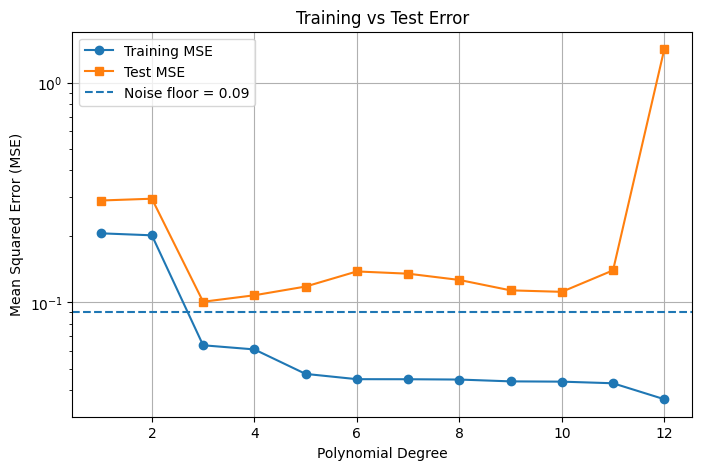

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    train_mse,
    "o-",
    label="Training MSE"
)

plt.plot(
    degrees,
    test_mse,
    "s-",
    label="Test MSE"
)

# Noise floor
plt.axhline(
    SIGMA**2,
    linestyle="--",
    label="Noise floor = 0.09"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Training vs Test Error")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()